In [46]:
from agentic_vnstock import AgenticVNStock
import pandas as pd
import time
import os

# Đặt tên file bạn muốn lưu
data_filepath = "stock_data_2020_2026.csv"

# BƯỚC 1: KIỂM TRA XEM FILE ĐÃ CÓ CHƯA
if os.path.exists(data_filepath):
    print(f"Đã tìm thấy file '{data_filepath}'. Đang tải dữ liệu từ máy tính (rất nhanh)...")
    # Đọc file CSV
    final_df = pd.read_csv(data_filepath)
    
    # Mẹo: Khi lưu CSV, cột thời gian (Date/Time) thường bị chuyển thành dạng Text (String).
    # Tùy thuộc vào cột thời gian của bạn tên là gì (thường là 'time' hoặc 'Date'), bạn ép kiểu lại cho chuẩn:
    if 'time' in final_df.columns:
        final_df['time'] = pd.to_datetime(final_df['time'])
    elif 'Date' in final_df.columns:
        final_df['Date'] = pd.to_datetime(final_df['Date'])
        
    print(f"Tải xong! Dữ liệu có {len(final_df)} dòng.")

# BƯỚC 2: NẾU CHƯA CÓ FILE, TIẾN HÀNH TẢI TỪ API VÀ LƯU LẠI
else:
    print("Chưa có dữ liệu sẵn. Đang tiến hành tải từ thư viện vnstock...")
    client = AgenticVNStock()

    # Danh sách ban đầu của bạn
    tickers = [
        "BCM", "BVH", "CTG", "FPT", "GVR", "HDB",  "MWG", "PLX", "POW", "SAB", "SHB", "SSB", "STB", 
        "TCB", "TPB", "VIB", "VIC", "VJC", "VPB", "VRE",
        "DGC", "KBC", "DIG", "HSG", "NKG", "VCG", "KDH", "GEX",
        "VCB","BID",
        "VHM","KDH","NVL","PDR",
        "VNM","MSN","SAB", "HAG",
        "HPG", "HSG", "VGC", "KSB",
        "GAS","PLX", "PVS", "PVD",
        "MWG","PNJ", "MSN", "SCS", "BWE",
        "SSI", "MBS", "HCM", "VND",
        "GMD","VSC", "HAH", "VTP", "DVP"
    ]
    
    # (Lưu ý nhỏ: Danh sách của bạn đang có một vài mã bị trùng lặp như KDH, SAB, PLX, MWG, MSN, HSG. 
    # Bạn có thể dùng list(set(tickers)) để loại bỏ mã trùng nếu muốn nhé)
    tickers = list(set(tickers)) 
    
    all_data = []

    for ticker in tickers:
        try:
            # Sửa lại câu in một chút để biết đang chạy đến mã nào
            print(f"Fetching {ticker} - OK") 
            df = client.get_stock_historical(ticker, "2020-01-01", "2026-04-21")
            df["ticker"] = ticker
            all_data.append(df)
            time.sleep(1)
        except Exception as e:
            print(f"Error {ticker}: {e}")

    final_df = pd.concat(all_data, ignore_index=True)
    
    # LƯU LẠI THÀNH FILE CSV CHO CÁC LẦN CHẠY SAU
    final_df.to_csv(data_filepath, index=False)
    print(f"Đã tải xong và lưu toàn bộ dữ liệu vào file '{data_filepath}'. Từ giờ bạn không cần đợi nữa!")

# Xong xuôi, bạn có thể in thử vài dòng để kiểm tra
print("\n--- BẢN XEM TRƯỚC DỮ LIỆU ---")
print(final_df.head())

Đã tìm thấy file 'stock_data_2020_2026.csv'. Đang tải dữ liệu từ máy tính (rất nhanh)...
Tải xong! Dữ liệu có 84485 dòng.

--- BẢN XEM TRƯỚC DỮ LIỆU ---
        Date   Open   High    Low  Close   Volume ticker
0 2020-01-02  38.97  39.48  38.75  39.22   386290    VCB
1 2020-01-03  39.52  39.66  38.84  38.84   536130    VCB
2 2020-01-06  38.54  38.66  37.79  37.79   880110    VCB
3 2020-01-07  37.58  37.97  36.89  37.92  1013270    VCB
4 2020-01-08  37.54  37.97  37.24  37.58   722280    VCB


In [26]:
# kiểm tra có trùng không
print("Duplicate rows:", final_df.duplicated(subset=["Date", "ticker"]).sum())

# loại bỏ trùng
final_df = final_df.drop_duplicates(subset=["Date", "ticker"])

Duplicate rows: 57


In [27]:
price_df = final_df.pivot(index="Date", columns="ticker", values="Close")
price_df = price_df.sort_index().ffill()

In [28]:
returns = price_df.pct_change().dropna()

print("Returns shape:", returns.shape)

Returns shape: (1265, 54)


In [29]:
valid_tickers = returns.columns[returns.count() > 500]
returns = returns[valid_tickers]

In [30]:
vol = returns.std()

returns = returns.loc[:, vol < 0.05]  # loại mã quá biến động

In [31]:
mean_returns = returns.mean()
volatility = returns.std()

rf = 0.03 / 252
sharpe = (mean_returns - rf) / volatility

def zscore(x):
    return (x - x.mean()) / x.std()

score = (
    0.4 * zscore(mean_returns) +
    0.4 * zscore(sharpe) -
    0.2 * zscore(volatility)
)

top6 = score.sort_values(ascending=False).head(6)

print(top6)

ticker
HAH    1.890217
VIC    1.280335
HDB    1.144022
DVP    1.075192
STB    1.057120
GMD    0.939014
dtype: float64


In [32]:
selected_tickers = ["HAH","VIC","HDB","DVP","STB","GMD"]

selected_returns = returns[selected_tickers]

mean_sel = selected_returns.mean()
cov_sel = selected_returns.cov()

In [33]:
import numpy as np

n = len(selected_tickers)
weights = np.ones(n) / n

port_return = np.dot(weights, mean_sel)
port_vol = np.sqrt(weights.T @ cov_sel @ weights)

print("Return:", port_return)
print("Risk:", port_vol)

Return: 0.0012884770940666077
Risk: 0.014065000489163579


In [34]:
from scipy.optimize import minimize

rf = 0.03 / 252

def neg_sharpe(w):
    ret = np.dot(w, mean_sel)
    vol = np.sqrt(w.T @ cov_sel @ w)
    return -(ret - rf) / vol

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0.05,1)] * n

init = np.ones(n) / n

opt = minimize(neg_sharpe, init, method='SLSQP',
               bounds=bounds, constraints=constraints)

opt_weights = opt.x

print("\nOptimal weights:")
for t, w in zip(selected_tickers, opt_weights):
    print(t, round(w,3))


Optimal weights:
HAH 0.209
VIC 0.24
HDB 0.124
DVP 0.287
STB 0.09
GMD 0.05


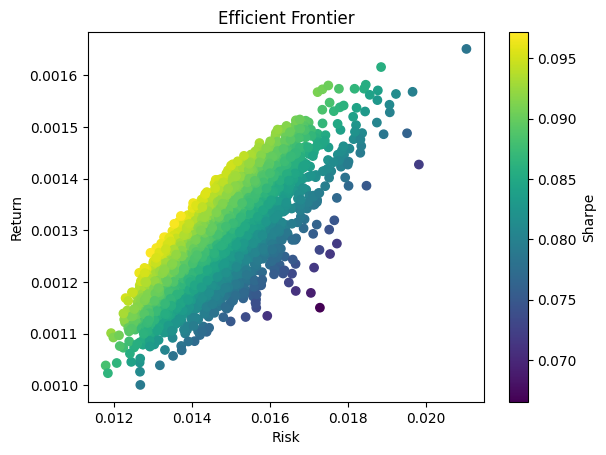

In [36]:
num_portfolios = 3000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    w = np.random.random(n)
    w /= np.sum(w)
    
    ret = np.dot(w, mean_sel)
    vol = np.sqrt(w.T @ cov_sel @ w)
    
    results[0,i] = vol
    results[1,i] = ret
    results[2,i] = ret / vol

import matplotlib.pyplot as plt

plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis')
plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe")
plt.show()

In [37]:
portfolio_returns = selected_returns.dot(opt_weights)

VaR_95 = np.percentile(portfolio_returns, 5)

print("VaR 95%:", VaR_95)

VaR 95%: -0.02205476482830923


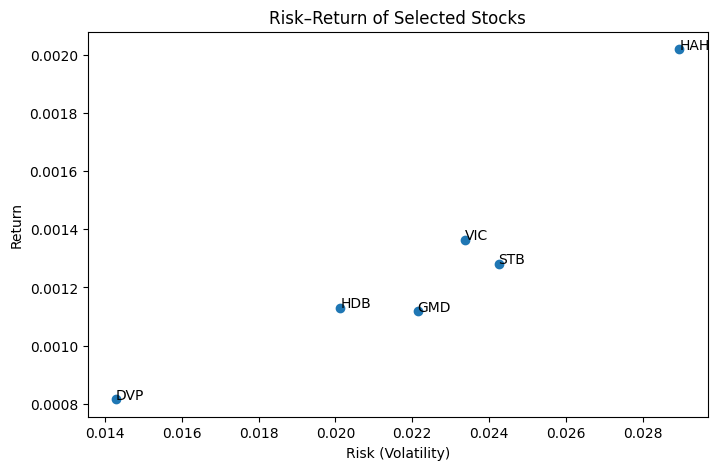

In [38]:
import matplotlib.pyplot as plt

vol = selected_returns.std()
ret = selected_returns.mean()

plt.figure(figsize=(8,5))
plt.scatter(vol, ret)

for t in selected_tickers:
    plt.annotate(t, (vol[t], ret[t]))

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk–Return of Selected Stocks")
plt.show()

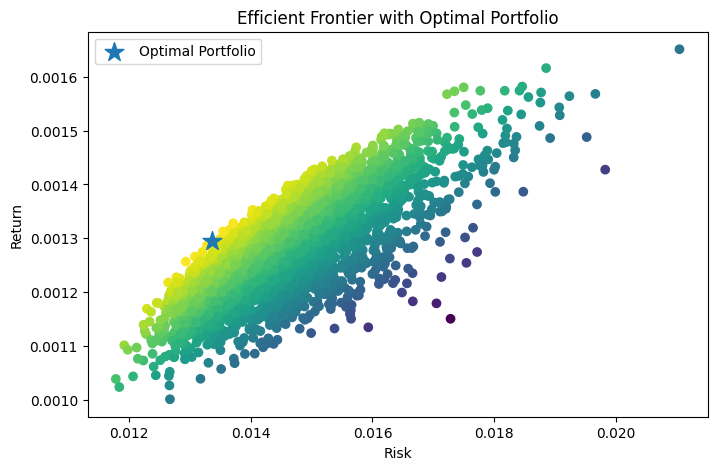

In [39]:
# điểm tối ưu
opt_ret = np.dot(opt_weights, mean_sel)
opt_vol = np.sqrt(opt_weights.T @ cov_sel @ opt_weights)

plt.figure(figsize=(8,5))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis')
plt.scatter(opt_vol, opt_ret, marker='*', s=200, label='Optimal Portfolio')

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier with Optimal Portfolio")
plt.legend()
plt.show()

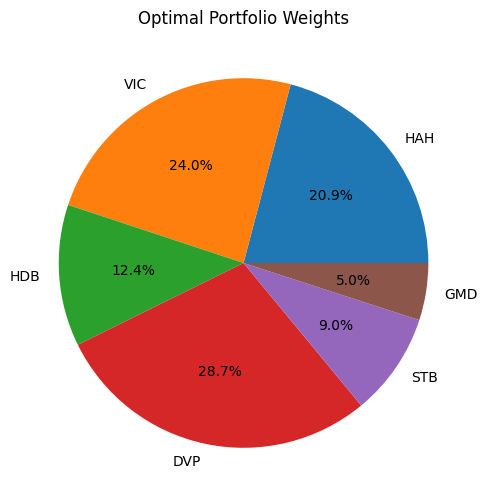

In [40]:
plt.figure(figsize=(6,6))
plt.pie(opt_weights, labels=selected_tickers, autopct='%1.1f%%')
plt.title("Optimal Portfolio Weights")
plt.show()

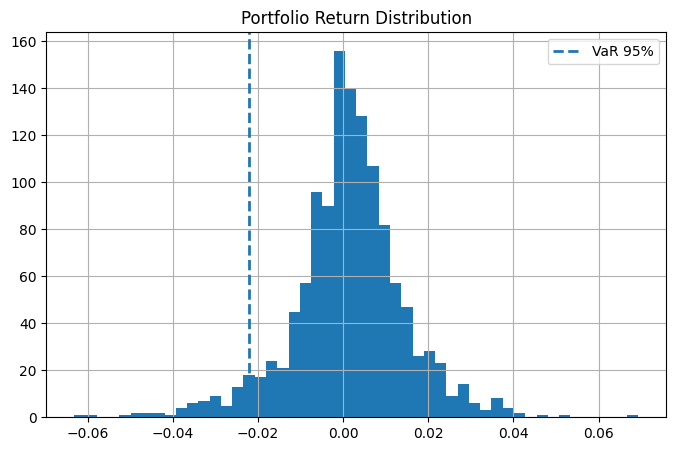

In [41]:
plt.figure(figsize=(8,5))
portfolio_returns.hist(bins=50)

plt.axvline(VaR_95, linestyle='dashed', linewidth=2, label='VaR 95%')
plt.legend()

plt.title("Portfolio Return Distribution")
plt.show()

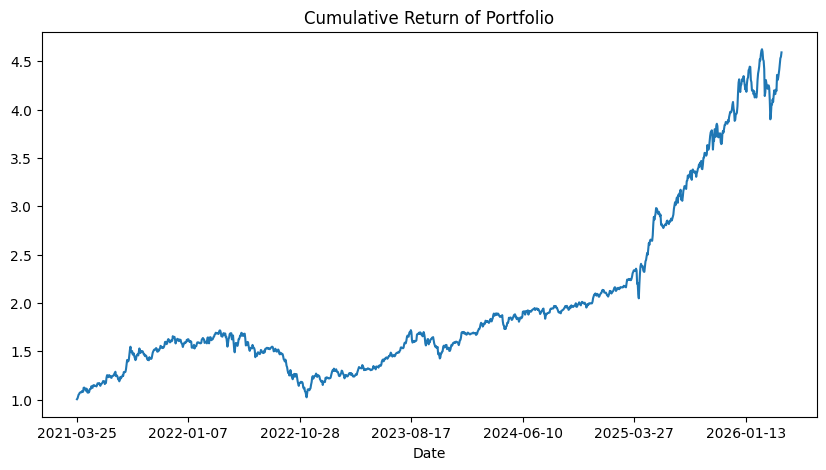

In [42]:
portfolio_returns = selected_returns.dot(opt_weights)
cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.plot(figsize=(10,5))
plt.title("Cumulative Return of Portfolio")
plt.show()

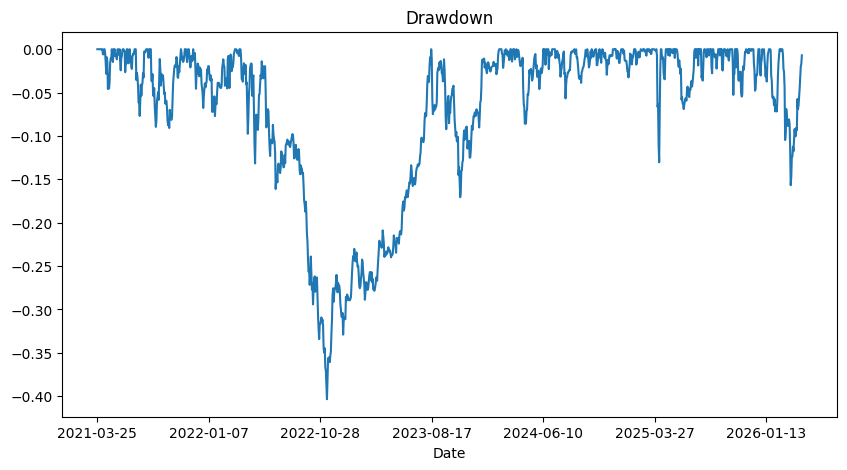

In [43]:
cum = (1 + portfolio_returns).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak

drawdown.plot(figsize=(10,5))
plt.title("Drawdown")
plt.show()

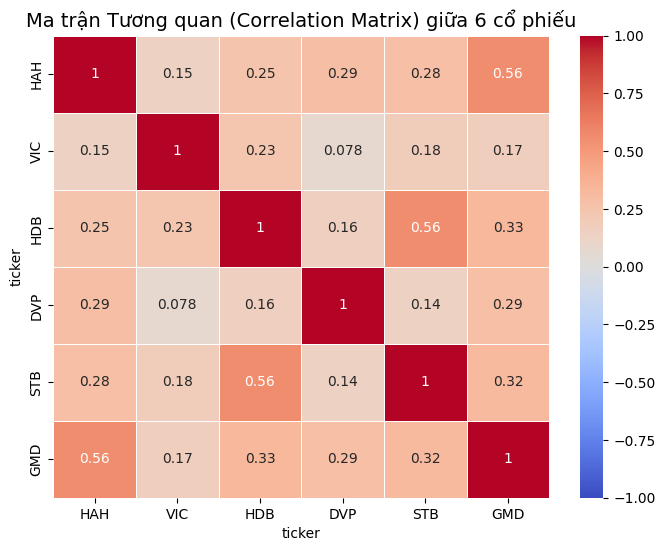

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Tính toán ma trận tương quan từ biến selected_returns bạn đã có
correlation_matrix = selected_returns.corr()

# Vẽ Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
plt.title("Ma trận Tương quan (Correlation Matrix) giữa 6 cổ phiếu", fontsize=14)
plt.show()

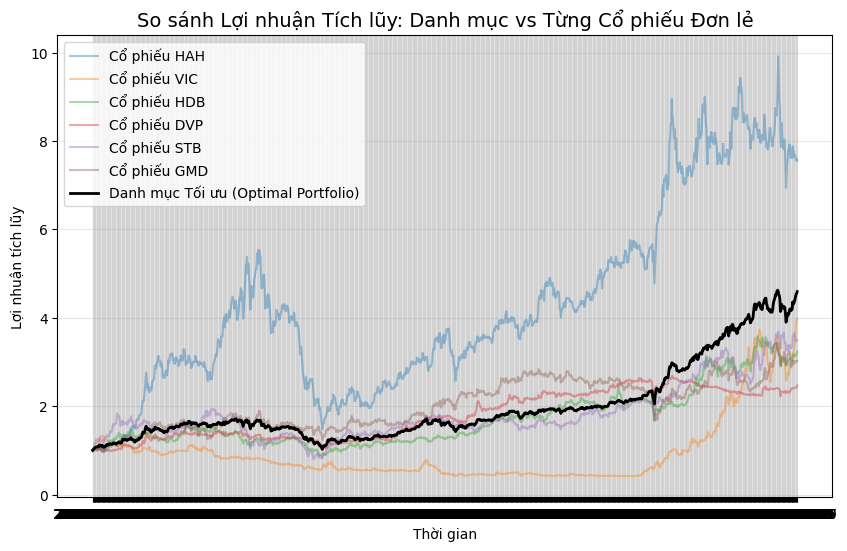

In [45]:
plt.figure(figsize=(10, 6))

# Tính lợi nhuận tích lũy của từng mã riêng lẻ
cum_selected = (1 + selected_returns).cumprod()

# Vẽ đường của 6 mã riêng lẻ (làm mờ bớt để làm nền)
for col in cum_selected.columns:
    plt.plot(cum_selected.index, cum_selected[col], alpha=0.4, label=f'Cổ phiếu {col}')

# Vẽ đường của Danh mục tối ưu (in đậm, màu nổi bật)
plt.plot(cumulative_returns.index, cumulative_returns, color='black', linewidth=2, label='Danh mục Tối ưu (Optimal Portfolio)')

plt.xlabel("Thời gian")
plt.ylabel("Lợi nhuận tích lũy")
plt.title("So sánh Lợi nhuận Tích lũy: Danh mục vs Từng Cổ phiếu Đơn lẻ", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()